## Questao 2 - Diagrama ACD e simulacao manual

Nesta questao, o consultorio medico e modelado como um sistema de filas com recepcao, triagem e atendimento medico.

### a) Identificacao do sistema

**Entidades:** pacientes.

**Recursos:** 1 recepcionista, 1 sala de triagem e 2 medicos.

**Filas:** fila da recepcao, fila da triagem e fila medica.

**Eventos:** chegada de paciente, fim de cadastro, fim de triagem e fim de consulta.

**Variaveis de estado:** relogio da simulacao, estado dos servidores, tamanho das filas e pacientes em atendimento.

### b) Diagrama ACD

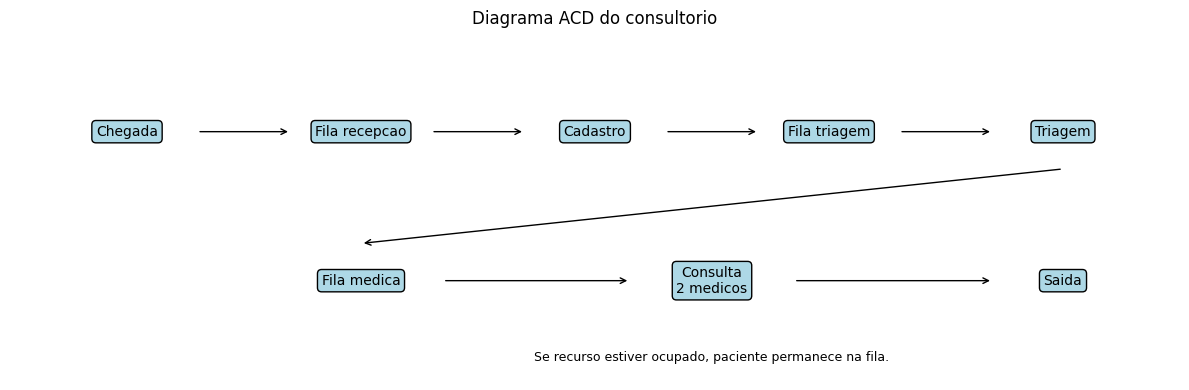

In [3]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 4))
ax.axis('off')

caixas = [
    ('Chegada', 0, 2),
    ('Fila recepcao', 2, 2),
    ('Cadastro', 4, 2),
    ('Fila triagem', 6, 2),
    ('Triagem', 8, 2),
    ('Fila medica', 2, 0.8),
    ('Consulta\n2 medicos', 5, 0.8),
    ('Saida', 8, 0.8)
]

for texto, x, y in caixas:
    ax.text(x, y, texto, ha='center', va='center', fontsize=10,
            bbox=dict(boxstyle='round', facecolor='lightblue', edgecolor='black'))

def seta(x1, y1, x2, y2):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1), arrowprops=dict(arrowstyle='->'))

seta(0.6, 2, 1.4, 2)
seta(2.6, 2, 3.4, 2)
seta(4.6, 2, 5.4, 2)
seta(6.6, 2, 7.4, 2)
seta(8, 1.7, 2, 1.1)
seta(2.7, 0.8, 4.3, 0.8)
seta(5.7, 0.8, 7.4, 0.8)

ax.text(5, 0.15, 'Se recurso estiver ocupado, paciente permanece na fila.', ha='center', fontsize=9)
ax.set_xlim(-1, 9)
ax.set_ylim(0, 2.8)
ax.set_title('Diagrama ACD do consultorio')
plt.tight_layout()
plt.show()

### c) Fases A, B e C

**Fase A:** avanca o relogio para o proximo evento.

**Fase B:** executa eventos incondicionais, como chegada, fim de cadastro, fim de triagem e fim de consulta.

**Fase C:** inicia atividades condicionais quando existe fila e recurso livre.

### d) Explicacao da dinamica

A cada passo, o relogio vai para o proximo evento. Quando um atendimento termina, o paciente e movido para a proxima fila ou sai do sistema. Depois disso, o simulador verifica se existe algum recurso livre. Se houver recurso livre e paciente aguardando, uma nova atividade e iniciada.

### e) Tabela manual

In [4]:
tempos_entre_chegadas = [5, 7, 3, 10, 6]
tempos_cadastro = [4, 5, 3, 4, 6]
tempos_triagem = [6, 5, 7, 4, 6]
tempos_consulta = [12, 18, 10, 20, 15]

chegadas = []
tempo = 0
for valor in tempos_entre_chegadas:
    tempo = tempo + valor
    chegadas.append(tempo)

recepcionista_livre = 0
triagem_livre = 0
medicos_livres = [0, 0]
tabela = []

for i in range(5):
    chegada = chegadas[i]

    inicio_cadastro = max(chegada, recepcionista_livre)
    fim_cadastro = inicio_cadastro + tempos_cadastro[i]
    recepcionista_livre = fim_cadastro

    inicio_triagem = max(fim_cadastro, triagem_livre)
    fim_triagem = inicio_triagem + tempos_triagem[i]
    triagem_livre = fim_triagem

    if medicos_livres[0] <= medicos_livres[1]:
        medico = 0
    else:
        medico = 1

    inicio_consulta = max(fim_triagem, medicos_livres[medico])
    fim_consulta = inicio_consulta + tempos_consulta[i]
    medicos_livres[medico] = fim_consulta

    tabela.append([
        i + 1, chegada, inicio_cadastro, fim_cadastro,
        inicio_triagem, fim_triagem, inicio_consulta, fim_consulta, medico + 1
    ])

print('Paciente | Chegada | Inicio Cadastro | Fim Cadastro | Inicio Triagem | Fim Triagem | Inicio Consulta | Fim Consulta | Medico')
for linha in tabela:
    print(linha)

Paciente | Chegada | Inicio Cadastro | Fim Cadastro | Inicio Triagem | Fim Triagem | Inicio Consulta | Fim Consulta | Medico
[1, 5, 5, 9, 9, 15, 15, 27, 1]
[2, 12, 12, 17, 17, 22, 22, 40, 2]
[3, 15, 17, 20, 22, 29, 29, 39, 1]
[4, 25, 25, 29, 29, 33, 39, 59, 1]
[5, 31, 31, 37, 37, 43, 43, 58, 2]


### f) Medidas de desempenho

In [5]:
espera_recepcao = []
espera_medica = []
tempo_sistema = []

for linha in tabela:
    paciente, chegada, inicio_cadastro, fim_cadastro, inicio_triagem, fim_triagem, inicio_consulta, fim_consulta, medico = linha

    espera_recepcao.append(inicio_cadastro - chegada)
    espera_medica.append(inicio_consulta - fim_triagem)
    tempo_sistema.append(fim_consulta - chegada)

tempo_medio_fila_recepcao = sum(espera_recepcao) / len(espera_recepcao)
tempo_medio_fila_medica = sum(espera_medica) / len(espera_medica)
tempo_medio_sistema = sum(tempo_sistema) / len(tempo_sistema)

tempo_final = max(linha[7] for linha in tabela)
tempo_ocupado_medicos = sum(tempos_consulta)
utilizacao_medicos = tempo_ocupado_medicos / (2 * tempo_final)

eventos = []
for linha in tabela:
    chegada = linha[1]
    fim_consulta = linha[7]
    eventos.append((chegada, 1))
    eventos.append((fim_consulta, -1))

eventos.sort()

area = 0
pacientes_sistema = 0
tempo_anterior = 0

for tempo, variacao in eventos:
    area = area + pacientes_sistema * (tempo - tempo_anterior)
    pacientes_sistema = pacientes_sistema + variacao
    tempo_anterior = tempo

numero_medio_sistema = area / tempo_final

print(f'Tempo medio na fila da recepcao: {tempo_medio_fila_recepcao:.2f} min')
print(f'Tempo medio na fila medica: {tempo_medio_fila_medica:.2f} min')
print(f'Tempo medio total no sistema: {tempo_medio_sistema:.2f} min')
print(f'Taxa de utilizacao dos medicos: {utilizacao_medicos * 100:.2f}%')
print(f'Numero medio de pacientes no sistema: {numero_medio_sistema:.2f}')

Tempo medio na fila da recepcao: 0.40 min
Tempo medio na fila medica: 1.20 min
Tempo medio total no sistema: 27.00 min
Taxa de utilizacao dos medicos: 63.56%
Numero medio de pacientes no sistema: 2.29
